In [1]:
!pip install -q scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.2 MB/s eta 0:00:00


       SISTEMA FUZZY - CONTROLE DO VENTILADOR
Temperatura: 10°C -> Velocidade do ventilador: 16.67%
Temperatura: 20°C -> Velocidade do ventilador: 44.05%
Temperatura: 25°C -> Velocidade do ventilador: 50.00%
Temperatura: 30°C -> Velocidade do ventilador: 55.95%
Temperatura: 38°C -> Velocidade do ventilador: 83.33%


          GRAUS DE PERTINÊNCIA

Temperatura: 10°C
Frio   = 1.00
Morno  = 0.00
Quente = 0.00

Temperatura: 20°C
Frio   = 0.50
Morno  = 0.50
Quente = 0.00

Temperatura: 25°C
Frio   = 0.00
Morno  = 1.00
Quente = 0.00

Temperatura: 30°C
Frio   = 0.00
Morno  = 0.50
Quente = 0.50

Temperatura: 38°C
Frio   = 0.00
Morno  = 0.00
Quente = 1.00


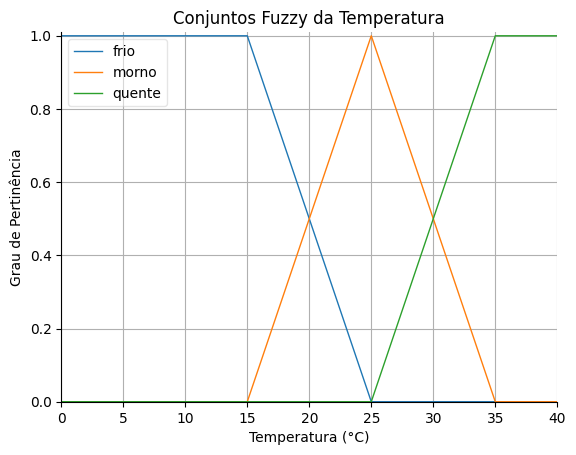

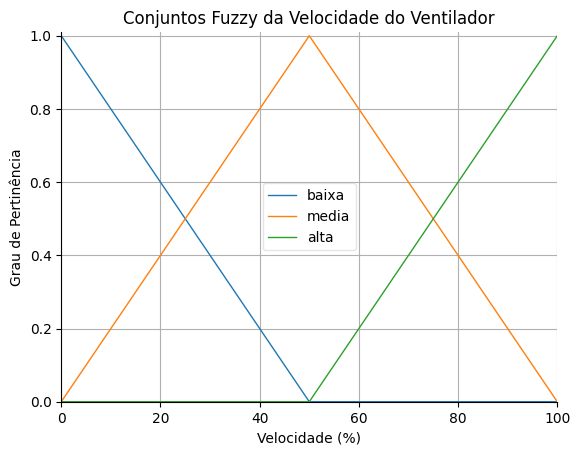

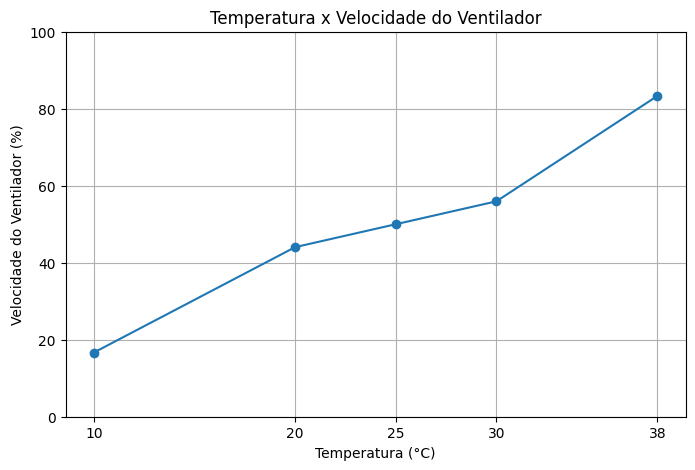



                TESTE INDIVIDUAL
Temperatura informada: 30°C
Velocidade calculada pelo sistema fuzzy: 55.95%


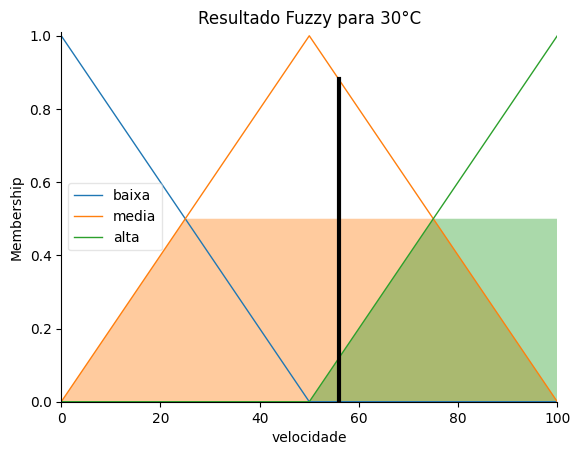



                     CONCLUSÃO

A lógica fuzzy permite controlar a velocidade do ventilador
de forma gradual de acordo com a temperatura.

As temperaturas são classificadas nos conjuntos:
- Frio
- Morno
- Quente

A velocidade do ventilador é classificada como:
- Baixa
- Média
- Alta

Uma temperatura pode pertencer parcialmente a mais de um
conjunto ao mesmo tempo.

Por exemplo, uma determinada temperatura pode ser parcialmente
fria e parcialmente morna.

O sistema utiliza os graus de pertinência e as regras fuzzy para
determinar a velocidade adequada do ventilador.

Depois da aplicação das regras, é realizada a defuzzificação,
transformando o resultado fuzzy em um valor numérico de
velocidade entre 0% e 100%.

Dessa forma, a velocidade do ventilador aumenta gradualmente
conforme a temperatura aumenta, evitando mudanças bruscas.



In [2]:
# ==============================================================================
# AULA 09 — SPRINT 1 (AC-3)
# MODELAGEM DAS VARIÁVEIS E CONJUNTOS FUZZY
#
# Sistema Fuzzy para Controle de Velocidade de um Ventilador
# ==============================================================================

# 1) IMPORTAÇÃO DAS BIBLIOTECAS

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt


# ==============================================================================
# 2) CRIAÇÃO DAS VARIÁVEIS LINGUÍSTICAS
# ==============================================================================

# Entrada: temperatura de 0°C até 40°C
temperatura = ctrl.Antecedent(
    np.arange(0, 41, 1),
    "temperatura"
)

# Saída: velocidade do ventilador de 0% até 100%
velocidade = ctrl.Consequent(
    np.arange(0, 101, 1),
    "velocidade"
)


# ==============================================================================
# 3) CRIAÇÃO DOS CONJUNTOS FUZZY
# ==============================================================================

# -------------------------
# TEMPERATURA
# -------------------------

# Temperatura FRIA
temperatura["frio"] = fuzz.trapmf(
    temperatura.universe,
    [0, 0, 15, 25]
)

# Temperatura MORNA
temperatura["morno"] = fuzz.trimf(
    temperatura.universe,
    [15, 25, 35]
)

# Temperatura QUENTE
temperatura["quente"] = fuzz.trapmf(
    temperatura.universe,
    [25, 35, 40, 40]
)


# -------------------------
# VELOCIDADE DO VENTILADOR
# -------------------------

# Velocidade BAIXA
velocidade["baixa"] = fuzz.trimf(
    velocidade.universe,
    [0, 0, 50]
)

# Velocidade MÉDIA
velocidade["media"] = fuzz.trimf(
    velocidade.universe,
    [0, 50, 100]
)

# Velocidade ALTA
velocidade["alta"] = fuzz.trimf(
    velocidade.universe,
    [50, 100, 100]
)


# ==============================================================================
# 4) CRIAÇÃO DAS REGRAS FUZZY
# ==============================================================================

# SE temperatura for FRIA
# ENTÃO velocidade será BAIXA
regra1 = ctrl.Rule(
    temperatura["frio"],
    velocidade["baixa"]
)

# SE temperatura for MORNA
# ENTÃO velocidade será MÉDIA
regra2 = ctrl.Rule(
    temperatura["morno"],
    velocidade["media"]
)

# SE temperatura for QUENTE
# ENTÃO velocidade será ALTA
regra3 = ctrl.Rule(
    temperatura["quente"],
    velocidade["alta"]
)


# ==============================================================================
# 5) CRIAÇÃO DO SISTEMA DE CONTROLE
# ==============================================================================

sistema = ctrl.ControlSystem([
    regra1,
    regra2,
    regra3
])

ventilador = ctrl.ControlSystemSimulation(sistema)


# ==============================================================================
# 6) TESTE DO SISTEMA COM VÁRIAS TEMPERATURAS
# ==============================================================================

temperaturas_teste = [10, 20, 25, 30, 38]

resultados = []

print("=" * 65)
print("       SISTEMA FUZZY - CONTROLE DO VENTILADOR")
print("=" * 65)

for temp in temperaturas_teste:

    # Define a temperatura de entrada
    ventilador.input["temperatura"] = temp

    # Realiza o cálculo fuzzy
    ventilador.compute()

    # Obtém a velocidade calculada
    velocidade_calculada = ventilador.output["velocidade"]

    # Guarda o resultado
    resultados.append(velocidade_calculada)

    # Mostra o resultado
    print(
        f"Temperatura: {temp:2d}°C "
        f"-> Velocidade do ventilador: "
        f"{velocidade_calculada:.2f}%"
    )


# ==============================================================================
# 7) CÁLCULO DOS GRAUS DE PERTINÊNCIA
# ==============================================================================

print("\n")
print("=" * 65)
print("          GRAUS DE PERTINÊNCIA")
print("=" * 65)

for temp in temperaturas_teste:

    # Grau de pertinência no conjunto FRIO
    grau_frio = fuzz.interp_membership(
        temperatura.universe,
        temperatura["frio"].mf,
        temp
    )

    # Grau de pertinência no conjunto MORNO
    grau_morno = fuzz.interp_membership(
        temperatura.universe,
        temperatura["morno"].mf,
        temp
    )

    # Grau de pertinência no conjunto QUENTE
    grau_quente = fuzz.interp_membership(
        temperatura.universe,
        temperatura["quente"].mf,
        temp
    )

    print(f"\nTemperatura: {temp}°C")
    print(f"Frio   = {grau_frio:.2f}")
    print(f"Morno  = {grau_morno:.2f}")
    print(f"Quente = {grau_quente:.2f}")


# ==============================================================================
# 8) GRÁFICO DOS CONJUNTOS FUZZY DA TEMPERATURA
# ==============================================================================

temperatura.view()

plt.title("Conjuntos Fuzzy da Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Grau de Pertinência")
plt.grid()

plt.show()


# ==============================================================================
# 9) GRÁFICO DOS CONJUNTOS FUZZY DA VELOCIDADE
# ==============================================================================

velocidade.view()

plt.title("Conjuntos Fuzzy da Velocidade do Ventilador")
plt.xlabel("Velocidade (%)")
plt.ylabel("Grau de Pertinência")
plt.grid()

plt.show()


# ==============================================================================
# 10) GRÁFICO TEMPERATURA X VELOCIDADE
# ==============================================================================

plt.figure(figsize=(8, 5))

plt.plot(
    temperaturas_teste,
    resultados,
    marker="o"
)

plt.title("Temperatura x Velocidade do Ventilador")

plt.xlabel("Temperatura (°C)")
plt.ylabel("Velocidade do Ventilador (%)")

plt.xticks(temperaturas_teste)
plt.ylim(0, 100)

plt.grid()

plt.show()


# ==============================================================================
# 11) TESTE INDIVIDUAL
# ==============================================================================

# Temperatura escolhida para demonstração
temperatura_escolhida = 30

ventilador.input["temperatura"] = temperatura_escolhida

ventilador.compute()

resultado = ventilador.output["velocidade"]


print("\n")
print("=" * 65)
print("                TESTE INDIVIDUAL")
print("=" * 65)

print(f"Temperatura informada: {temperatura_escolhida}°C")

print(
    f"Velocidade calculada pelo sistema fuzzy: "
    f"{resultado:.2f}%"
)


# ==============================================================================
# 12) MOSTRAR GRAFICAMENTE O RESULTADO DO TESTE
# ==============================================================================

velocidade.view(sim=ventilador)

plt.title(
    f"Resultado Fuzzy para {temperatura_escolhida}°C"
)

plt.show()


# ==============================================================================
# 13) CONCLUSÃO NO CONSOLE
# ==============================================================================

print("\n")
print("=" * 65)
print("                     CONCLUSÃO")
print("=" * 65)

print("""
A lógica fuzzy permite controlar a velocidade do ventilador
de forma gradual de acordo com a temperatura.

As temperaturas são classificadas nos conjuntos:
- Frio
- Morno
- Quente

A velocidade do ventilador é classificada como:
- Baixa
- Média
- Alta

Uma temperatura pode pertencer parcialmente a mais de um
conjunto ao mesmo tempo.

Por exemplo, uma determinada temperatura pode ser parcialmente
fria e parcialmente morna.

O sistema utiliza os graus de pertinência e as regras fuzzy para
determinar a velocidade adequada do ventilador.

Depois da aplicação das regras, é realizada a defuzzificação,
transformando o resultado fuzzy em um valor numérico de
velocidade entre 0% e 100%.

Dessa forma, a velocidade do ventilador aumenta gradualmente
conforme a temperatura aumenta, evitando mudanças bruscas.
""")